# CodeIndex — End-to-end pipeline

Walk a project, hash every file, build a Merkle tree, chunk Python files, embed every chunk, build a hybrid index, search it, and rerank.

**Each cell uses the actual `codeindex/*` modules** so you can see the full pipeline working on a real repo. We point it at this project itself.

In [1]:
from pathlib import Path
import tempfile
from dotenv import load_dotenv
load_dotenv()

REPO_PATH = Path("/home/krishp/Downloads/code_indexer/CodeIndex")
ARTIFACTS = Path(tempfile.mkdtemp(prefix="codeindex_"))
print(f"Indexing:  {REPO_PATH}")
print(f"Artifacts: {ARTIFACTS}")

Indexing:  /home/krishp/Downloads/code_indexer/CodeIndex
Artifacts: /tmp/codeindex_tz5xsfli


## 1. Walker — find source files

`walk(root)` does a recursive directory traversal and yields a `WalkedFile(absolute, relative)` for each file we want to index. It already handles allowed extensions, pruned dirs (`.git`, `__pycache__`, `.venv`, `node_modules`), `.gitignore` / `.indexignore`, symlinks, and a 1 MB size cap.

In [2]:
from codeindex.walker import walk

files = list(walk(REPO_PATH))
print(f"Found {len(files)} files\n")
for w in files[:10]:
    print(f"  {w.relative}")

Found 16 files

  README.md
  src/codeindex/__init__.py
  src/codeindex/chunker.py
  src/codeindex/embedder.py
  src/codeindex/hasher.py
  src/codeindex/merkle.py
  src/codeindex/reranker.py
  src/codeindex/retrieval.py
  src/codeindex/visualize.py
  src/codeindex/walker.py


## 2. Hasher — fingerprint every file

`hash_files(walked_files)` streams each file in 64KB chunks and yields `FileHash(relative, sha256, size)`. Streaming means a 100 MB file uses ~64 KB of RAM. SHA-256 means flipping a single byte changes the hash.

In [3]:
from codeindex.hasher import hash_files

file_hashes = list(hash_files(files))
print(f"Hashed {len(file_hashes)} files\n")
for fh in file_hashes[:5]:
    print(f"  {fh.sha256[:12]}…  size={fh.size:>6}  {fh.relative}")

Hashed 16 files

  7f0d70575a73…  size=   223  README.md
  09c57d2fdf3b…  size=    55  src/codeindex/__init__.py
  49c738afcd97…  size=  4049  src/codeindex/chunker.py
  6535f85dc14e…  size=  1080  src/codeindex/embedder.py
  0a1b14df528a…  size=   793  src/codeindex/hasher.py


### Visualize: file sizes

Quick eyeball of which files are biggest in the repo.

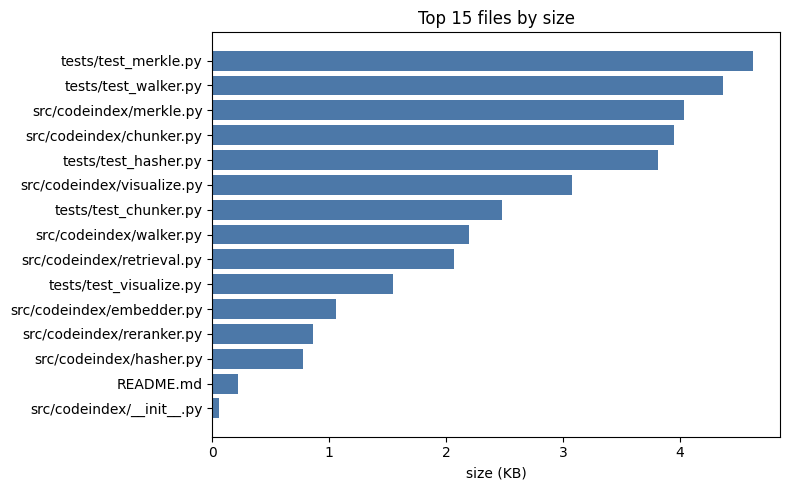

In [4]:
import matplotlib.pyplot as plt

top = sorted(file_hashes, key=lambda fh: -fh.size)[:15]
names = [str(fh.relative) for fh in reversed(top)]
sizes_kb = [fh.size / 1024 for fh in reversed(top)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names, sizes_kb, color="#4c78a8")
ax.set_xlabel("size (KB)")
ax.set_title("Top 15 files by size")
plt.tight_layout()
plt.show()

## 3. Merkle tree — fingerprint the whole repo

`build_tree(file_hashes)` arranges files into a tree mirroring the directory layout. Each directory's hash is computed bottom-up from its children's `(kind, name, hash)` lines. One file changes → the file's leaf hash changes → every ancestor's hash changes → root hash changes. Sibling subtrees that didn't change keep the **same** hash — that's the basis for cheap incremental indexing.

In [5]:
from codeindex.merkle import build_tree

tree = build_tree(file_hashes)

print(f"root hash: {tree.sha256}")
print(f"root has {len(tree.children)} top-level entries:")
for child in tree.children[:10]:
    kind = "dir" if child.is_dir else "file"
    print(f"  [{kind:4s}] {child.sha256[:8]}…  {child.name}")

root hash: c937067021768e600f105600afcc256cde62de889c02c858d3e6e55c2cb5d771
root has 3 top-level entries:
  [file] 7f0d7057…  README.md
  [dir ] 50d2cb23…  src
  [dir ] b17e29fd…  tests


### Diff a simulated change

Pretend on the next run one file's bytes are different. `diff(old, new)` walks both trees in parallel, short-circuits on equal-hash subtrees, and tells us exactly what changed.

In [6]:
import hashlib
from codeindex.hasher import FileHash
from codeindex.merkle import diff

modified = list(file_hashes)
if modified:
    fh = modified[0]
    modified[0] = FileHash(fh.relative, hashlib.sha256(b"new bytes").hexdigest(), fh.size)

new_tree = build_tree(modified)
changes = diff(tree, new_tree)

print(f"added:    {sorted(changes.added)}")
print(f"removed:  {sorted(changes.removed)}")
print(f"modified: {sorted(changes.modified)}")

added:    []
removed:  []
modified: [PosixPath('README.md')]


### Visualize: the Merkle tree with changes highlighted

`visualize.render()` draws the tree as a Graphviz graph. Modified files glow orange, dirs that contain a change get a bold orange border so you can trace the change up to root. (Needs the `dot` binary installed.)

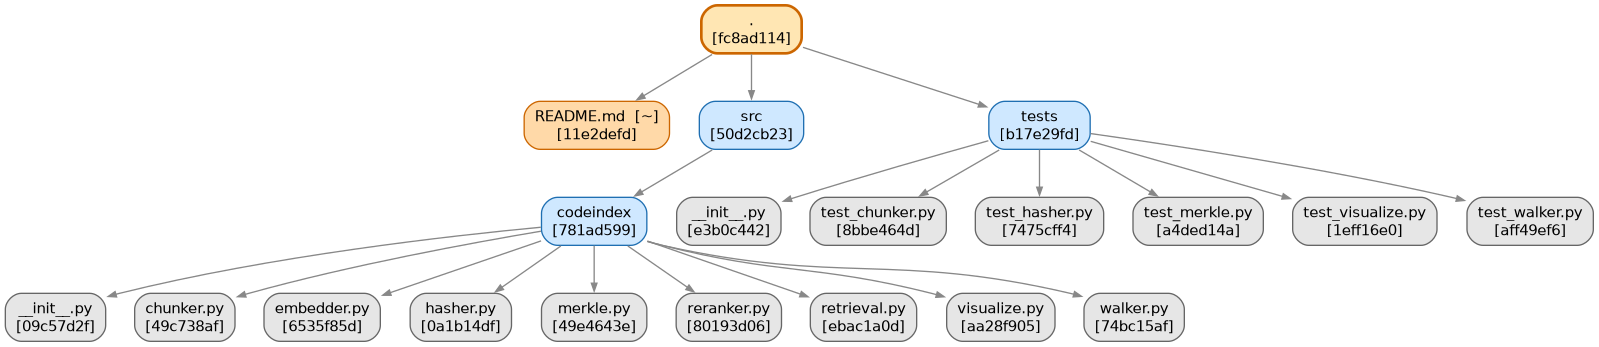

In [7]:
from IPython.display import Image, display
from codeindex.visualize import render

tree_png = render(new_tree, ARTIFACTS / "tree.png", changes=changes)
display(Image(filename=str(tree_png)))

## 4. Chunker — split each Python file into embedding-ready pieces

`chunk_file(file_hash, content)` parses with `tree-sitter-python`, walks the AST, and emits one `Chunk` per top-level **function**, **class**, **method**, or **decorated definition**. Big functions get line-split with the same `kind`/`name`. Each chunk has a stable `chunk_id = sha256[:16]:<start>-<end>`.

In [8]:
from codeindex.chunker import chunk_file

chunks = []
for fh in file_hashes:
    if fh.relative.suffix.lower() != ".py":
        continue
    content = (REPO_PATH / fh.relative).read_bytes()
    chunks.extend(chunk_file(fh, content))

print(f"Produced {len(chunks)} chunks\n")
for c in chunks[:8]:
    print(f"  [{c.kind:8s}] {c.name:25s}  {c.relative}:{c.start_line}-{c.end_line}")

Produced 112 chunks

  [function] main                       src/codeindex/__init__.py:1-2
  [function] Chunk                      src/codeindex/chunker.py:26-34
  [class   ] Chunk                      src/codeindex/chunker.py:27-34
  [function] chunk_file                 src/codeindex/chunker.py:37-53
  [function] _walk_chunkable_nodes      src/codeindex/chunker.py:56-60
  [function] _chunks_for_node           src/codeindex/chunker.py:63-77
  [function] _make_chunk                src/codeindex/chunker.py:80-99
  [function] _name_of                   src/codeindex/chunker.py:102-110


### Visualize: chunks per file & kind distribution

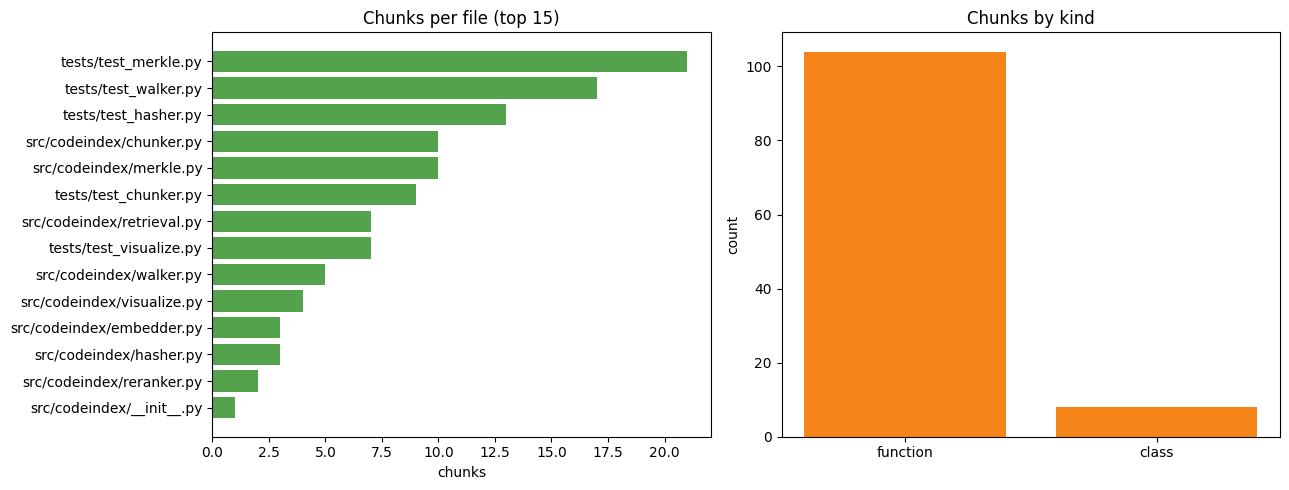

In [9]:
from collections import Counter

per_file = Counter(str(c.relative) for c in chunks).most_common(15)
by_kind = Counter(c.kind for c in chunks)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

names = [n for n, _ in reversed(per_file)]
counts = [v for _, v in reversed(per_file)]
ax1.barh(names, counts, color="#54a24b")
ax1.set_xlabel("chunks")
ax1.set_title("Chunks per file (top 15)")

ax2.bar(by_kind.keys(), by_kind.values(), color="#f58518")
ax2.set_ylabel("count")
ax2.set_title("Chunks by kind")

plt.tight_layout()
plt.show()

## 5. Embedder — turn each chunk into a vector

`embed_chunks(chunks)` batches chunk content through OpenAI's `text-embedding-3-small` (1536-dim) and returns `Embedding(chunk_id, vector)` for each. **Requires `OPENAI_API_KEY` in your environment.**

In [10]:
from codeindex.embedder import embed_chunks

embeddings = embed_chunks(chunks)

print(f"Embedded {len(embeddings)} chunks  (dim={len(embeddings[0].vector)})")

Embedded 112 chunks  (dim=1536)


## 6. Build the hybrid index

`build_index(chunks, embeddings)` L2-normalizes vectors so cosine = dot product, builds a BM25 index over chunk content (camelCase + non-alphanum tokenization), and keeps the chunk list ordered for index-back lookups.

In [11]:
from codeindex.retrieval import build_index

index = build_index(chunks, embeddings)

print(f"index.chunks:  {len(index.chunks)}")
print(f"index.vectors: shape={index.vectors.shape}, dtype={index.vectors.dtype}")

index.chunks:  112
index.vectors: shape=(112, 1536), dtype=float32


### Visualize: similarity heatmap between a few chunks

A sanity check that close-by code (e.g. methods on the same class) has higher cosine similarity than unrelated code.

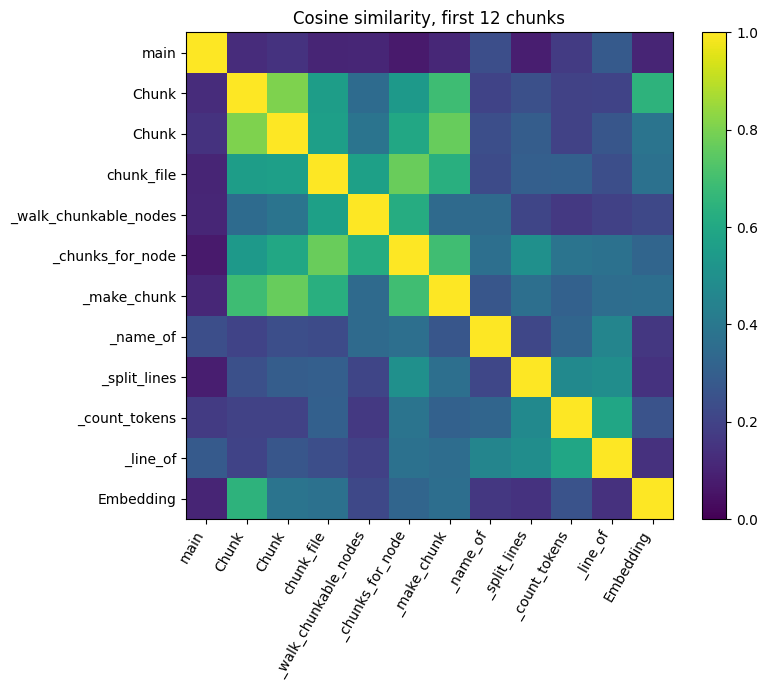

In [12]:
import numpy as np

k = min(12, len(index.vectors))
subset = index.vectors[:k]
labels = [f"{c.name}" for c in index.chunks[:k]]
sim = subset @ subset.T

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(k), labels, rotation=60, ha="right")
ax.set_yticks(range(k), labels)
ax.set_title(f"Cosine similarity, first {k} chunks")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 7. Search

Embed the query with the same model, then run hybrid search. `search()` does dense (cosine) + BM25, fuses with **Reciprocal Rank Fusion**, returns the top-K. Try changing `QUERY` and re-running.

In [13]:
from openai import OpenAI
from codeindex.retrieval import search

QUERY = "how does the merkle tree detect changed files"

client = OpenAI()
qv = client.embeddings.create(model="text-embedding-3-small", input=[QUERY]).data[0].embedding

results = search(index, QUERY, qv, top_k=10)

print(f"Top {len(results)} hits for: {QUERY!r}\n")
for r in results:
    print(f"  {r.score:.4f}  {r.chunk.relative}:{r.chunk.start_line}-{r.chunk.end_line}  [{r.chunk.kind}] {r.chunk.name}")

Top 10 hits for: 'how does the merkle tree detect changed files'

  0.0320  src/codeindex/merkle.py:59-104  [function] _diff
  0.0317  src/codeindex/visualize.py:19-81  [function] render
  0.0313  src/codeindex/merkle.py:25-34  [function] build_tree
  0.0306  src/codeindex/merkle.py:53-56  [function] diff
  0.0286  src/codeindex/merkle.py:37-50  [function] _build_node
  0.0284  tests/test_merkle.py:18-28  [function] test_single_file
  0.0283  src/codeindex/merkle.py:107-112  [function] _collect_files
  0.0282  src/codeindex/visualize.py:43-71  [function] walk
  0.0275  src/codeindex/merkle.py:12-16  [class] MerkleNode
  0.0269  tests/test_merkle.py:49-52  [function] test_empty_input


### Visualize: dense vs BM25 vs RRF for this query

Recompute the three score lists separately so we can see which retriever found which chunk first. This is the same logic that's already inside `search()` — just exposed for the picture.

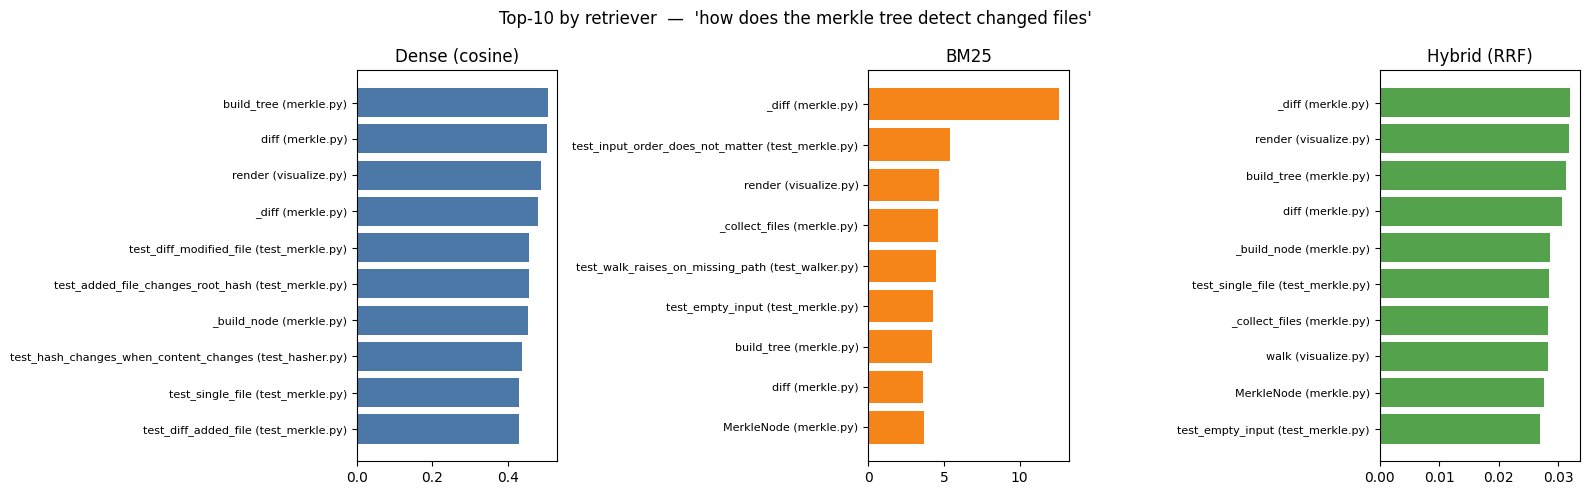

In [14]:
from codeindex.retrieval import _tokenize

qv_arr = np.array(qv, dtype=np.float32)
qv_arr = qv_arr / np.linalg.norm(qv_arr)
dense_scores = index.vectors @ qv_arr
bm25_scores = index.bm25.get_scores(_tokenize(QUERY))

k = 10
dense_idx = np.argsort(-dense_scores)[:k]
bm25_idx = np.argsort(-bm25_scores)[:k]
rrf_idx = [index.chunks.index(r.chunk) for r in results[:k]]

def label(i):
    c = index.chunks[i]
    return f"{c.name} ({c.relative.name})"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, idxs, scores, title, color in [
    (axes[0], dense_idx, dense_scores[dense_idx], "Dense (cosine)", "#4c78a8"),
    (axes[1], bm25_idx, bm25_scores[bm25_idx], "BM25", "#f58518"),
    (axes[2], rrf_idx, [r.score for r in results[:k]], "Hybrid (RRF)", "#54a24b"),
]:
    names = [label(int(i)) for i in idxs][::-1]
    vals = list(scores)[::-1]
    ax.barh(names, vals, color=color)
    ax.set_title(title)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle(f"Top-10 by retriever  —  {QUERY!r}")
plt.tight_layout()
plt.show()

## 8. Rerank

Hybrid retrieval is fast but coarse — both retrievers score chunks **independently** of the query. A cross-encoder reranker reads `(query, chunk)` together and re-scores. Slow per-pair, accurate. We feed it the top results from step 7 and trim to the final top-K. **First run downloads the model** (~80 MB).

In [15]:
from codeindex.reranker import rerank

top = rerank(QUERY, results, top_k=5)

print(f"Reranked top {len(top)} for: {QUERY!r}\n")
for r in top:
    print(f"  {r.score:+.3f}  {r.chunk.relative}:{r.chunk.start_line}-{r.chunk.end_line}  [{r.chunk.kind}] {r.chunk.name}")
    print(f"          {r.chunk.content.splitlines()[0][:80]}")

/home/krishp/Downloads/code_indexer/CodeIndex/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1903.58it/s]


Reranked top 5 for: 'how does the merkle tree detect changed files'

  +4.621  src/codeindex/merkle.py:59-104  [function] _diff
          def _diff(prefix: Path, old: MerkleNode | None, new: MerkleNode | None, out: Cha
  +1.814  src/codeindex/visualize.py:19-81  [function] render
          def render(
  -1.831  src/codeindex/merkle.py:53-56  [function] diff
          def diff(old: MerkleNode | None, new: MerkleNode | None) -> Changes:
  -2.505  src/codeindex/visualize.py:43-71  [function] walk
          def walk(node: MerkleNode, path: Path) -> str:
  -2.774  src/codeindex/merkle.py:25-34  [function] build_tree
          def build_tree(file_hashes: Iterable[FileHash]) -> MerkleNode:


### Visualize: how reranking shuffled the order

Each line shows where a chunk landed before vs after reranking. A line that crosses far means the cross-encoder strongly disagreed with hybrid retrieval.

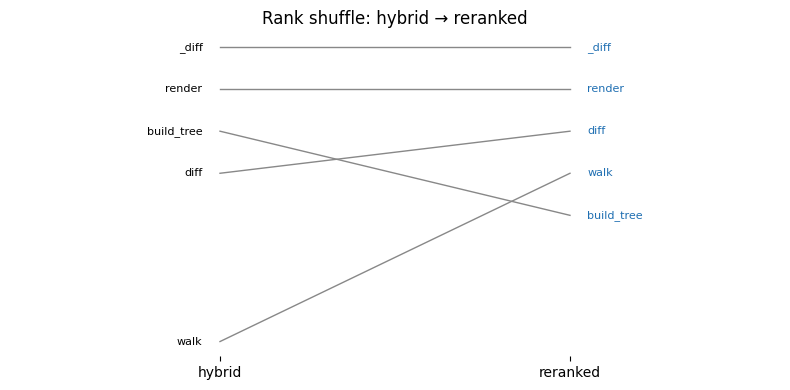

In [16]:
before = [r.chunk.chunk_id for r in results]
after = [r.chunk.chunk_id for r in top]

fig, ax = plt.subplots(figsize=(8, max(4, len(before) * 0.4)))
for new_rank, cid in enumerate(after):
    if cid in before:
        old_rank = before.index(cid)
        chunk = next(r.chunk for r in top if r.chunk.chunk_id == cid)
        ax.plot([0, 1], [old_rank, new_rank], color="#888", linewidth=1)
        ax.text(-0.05, old_rank, chunk.name, ha="right", va="center", fontsize=8)
        ax.text(1.05, new_rank, chunk.name, ha="left", va="center", fontsize=8, color="#1f6fb2")

ax.invert_yaxis()
ax.set_xticks([0, 1], ["hybrid", "reranked"])
ax.set_xlim(-0.6, 1.6)
ax.set_yticks([])
ax.set_title("Rank shuffle: hybrid → reranked")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

## Recap

```
REPO
  ↓ walker         → list of files (gitignore-aware, prune dirs, size cap)
  ↓ hasher         → SHA-256 per file
  ↓ merkle.build   → directory tree with bottom-up hashes
  ↓ merkle.diff    → cheap incremental: only re-process changed subtrees
  ↓ chunker        → AST-aware chunks per Python file (token-capped)
  ↓ embedder       → 1536-dim vectors via OpenAI
  ↓ retrieval      → in-memory hybrid (dense + BM25 + RRF)
  ↓ reranker       → local cross-encoder for the final top-K
RESULTS
```